# Statistical Modeling and Air Quality Prediction Using Beijing Multi-Site Data

## Introduction

This project analyzes air pollution patterns in Beijing using air quality and meteorological data collected from 12 monitoring stations between March 2013 and February 2017. The objective is to understand factors influencing air pollution levels and develop statistical models to predict PM2.5 concentrations using weather-related variables.

PM2.5 was selected as the primary target variable because it is a widely used indicator of air quality, exhibits substantial variation across seasons and locations, and is well suited for statistical analysis and predictive modeling.

## Dataset Overview

Dataset: Beijing Multi-Site Air Quality Dataset (UCI Repository)

Time Period:
- March 2013 – February 2017

Monitoring Stations:
- 12 stations across Beijing

Total Records:
- 420,768 hourly observations

Air Quality Variables:
- PM2.5
- PM10
- SO2
- NO2
- CO
- O3

Meteorological Variables:
- Temperature (TEMP)
- Pressure (PRES)
- Dew Point (DEWP)
- Rainfall (RAIN)
- Wind Speed (WSPM)
- Wind Direction (wd)

# Data Preparation and Cleaning 


## 1. Import Libraries and Load Raw Data

In [62]:
import pandas as pd
import glob
import os
from pathlib import Path

base_dir = "../datasets/raw"

csv_files = [
    file for file in os.listdir(base_dir)
    if file.endswith(".csv") and file.startswith("PRSA_Data")
]

print("Number of station files:", len(csv_files))
print(sorted(csv_files))

Number of station files: 12
['PRSA_Data_Aotizhongxin_20130301-20170228.csv', 'PRSA_Data_Changping_20130301-20170228.csv', 'PRSA_Data_Dingling_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Guanyuan_20130301-20170228.csv', 'PRSA_Data_Gucheng_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Nongzhanguan_20130301-20170228.csv', 'PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Wanliu_20130301-20170228.csv', 'PRSA_Data_Wanshouxigong_20130301-20170228.csv']


## 2. Combine Station-Level Datasets

In [ ]:
dataframes = []

#concat all station files into a single DataFrame

for file in csv_files:
    file_path = os.path.join(base_dir, file)

    temp_df = pd.read_csv(file_path)

    station_name = (
        file.replace("PRSA_Data_", "")
            .replace("_20130301-20170228.csv", "")
    )

    temp_df["station"] = station_name

    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)

print(df.shape)
df["station"].value_counts()

print("Shape:", df.shape)

print("\nNumber of stations:")
print(df["station"].nunique())

print("\nRows per station:")
print(df["station"].value_counts())

(420768, 18)
Shape: (420768, 18)

Number of stations:
12

Rows per station:
station
Gucheng          35064
Huairou          35064
Tiantan          35064
Changping        35064
Guanyuan         35064
Nongzhanguan     35064
Wanliu           35064
Dongsi           35064
Wanshouxigong    35064
Aotizhongxin     35064
Dingling         35064
Shunyi           35064
Name: count, dtype: int64


## 3. Save Combined Dataset

In [ ]:
# save the combined DataFrame to a new CSV file
df.to_csv(
    "../datasets/processed/beijing_air_quality_combined.csv",
    index=False
)

## 4. Create Datetime Feature


In [ ]:
# Create a datetime column from year, month, day, hour
df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

## 5. Dataset Overview


In [66]:

df.describe().round(2)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.00,420768.00,420768.00,420768.00,420768.00,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420365.00,420378.00,420450.00,420768
mean,17532.50,2014.66,6.52,15.73,11.50,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,2.49,0.06,1.73,2015-03-01 11:30:00.000001024
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00,2013-03-01 00:00:00
25%,8766.75,2014.00,4.00,8.00,5.75,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,-8.90,0.00,0.90,2014-03-01 05:45:00
50%,17532.50,2015.00,7.00,16.00,11.50,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,3.10,0.00,1.40,2015-03-01 11:30:00
75%,26298.25,2016.00,10.00,23.00,17.25,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,15.10,0.00,2.20,2016-02-29 17:15:00
max,35064.00,2017.00,12.00,31.00,23.00,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20,2017-02-28 23:00:00
std,10122.12,1.18,3.45,8.80,6.92,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,13.79,0.82,1.25,NaN


## 6. Data Type and Structure Review


In [67]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Stations:", df["station"].nunique())
print("Date Range:")
print(df["datetime"].min())
print(df["datetime"].max())


Rows: 420768
Columns: 19
Stations: 12
Date Range:
2013-03-01 00:00:00
2017-02-28 23:00:00


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  object        
 16  WSPM      420450 non-null  float64    

## 7. Missing Value Analysis


In [ ]:

# Missing Value Percentage

missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean() * 100, 2)
})

missing_df.sort_values(
    by="Missing %",
    ascending=False
)

,Missing Count,Missing %
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
RAIN,390,0.09
TEMP,398,0.09


In [70]:
df.groupby("station")["CO"].apply(
    lambda x: x.isnull().sum()
)

station
Aotizhongxin     1776
Changping        1521
Dingling         2012
Dongsi           3197
Guanyuan         1753
Gucheng          1401
Huairou          1422
Nongzhanguan     1206
Shunyi           2178
Tiantan          1126
Wanliu           1812
Wanshouxigong    1297
Name: CO, dtype: int64

#  Data Exploration, Visualization & Insights

## 8. Station-Level PM2.5 Analysis


### 8.1 Summary Statistics by Station

In [71]:
df.groupby("station")["PM2.5"] \
  .agg(["mean", "median", "std"]) \
  .sort_values("mean", ascending=False)

,mean,median,std
station,,,
Dongsi,86.194297,61.0,86.575127
Wanshouxigong,85.024136,60.0,85.975981
Nongzhanguan,84.838483,59.0,86.225344
Gucheng,83.852089,60.0,82.796445
Wanliu,83.374716,59.0,81.905568
Guanyuan,82.933372,59.0,80.933497
Aotizhongxin,82.773611,58.0,82.135694
Tiantan,82.164911,59.0,80.921384
Shunyi,79.491602,55.0,81.231739


### 8.2 Average PM2.5 Concentration by Station

<Axes: xlabel='station'>

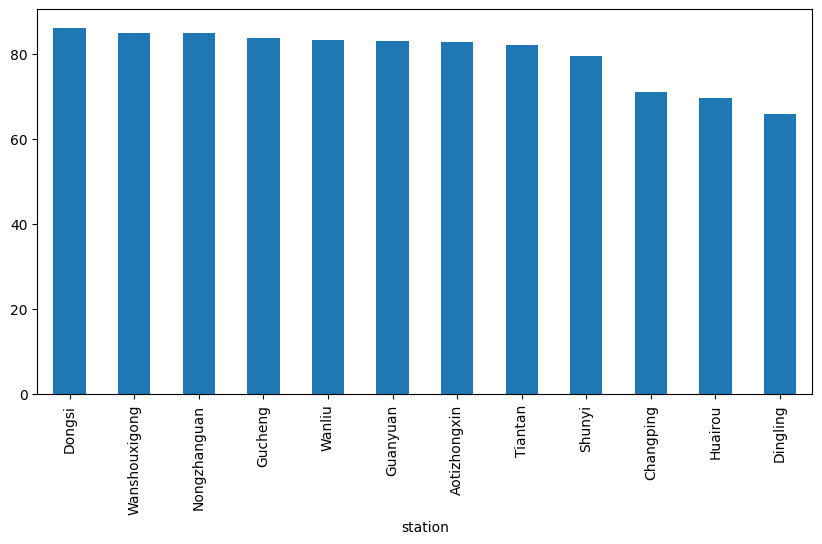

In [72]:
station_pm25 = (
    df.groupby("station")["PM2.5"]
      .mean()
      .sort_values(ascending=False)
)

station_pm25.plot(
    kind="bar",
    figsize=(10,5)
)

### 8.3 Distribution of PM2.5 Levels

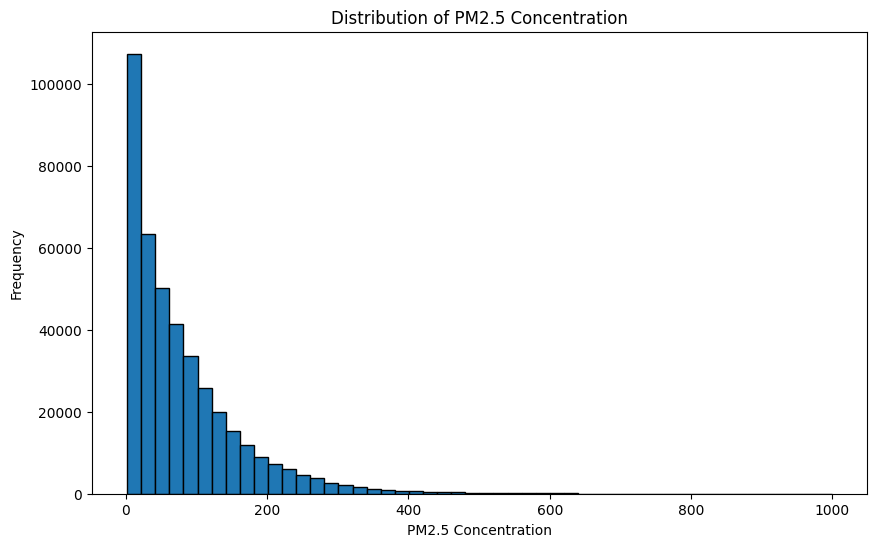

PM2.5 summary statistics:


count    412029.00
mean         79.79
std          80.82
min           2.00
25%          20.00
50%          55.00
75%         111.00
max         999.00
Name: PM2.5, dtype: float64

In [108]:
# Distribution of PM2.5

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df["PM2.5"], bins=50, edgecolor="black")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Concentration")
plt.show()

print("PM2.5 summary statistics:")
display(df["PM2.5"].describe().round(2))

The PM2.5 distribution is right-skewed, with most observations concentrated at lower values and a small number of extreme pollution events at higher concentrations. The mean exceeds the median, confirming the presence of positive skewness.

## 9. Seasonal PM2.5 Analysis


### 9.1 Summary Statistics by Season

In [ ]:
# Feature Engineering: Create a new column for season based on the month

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(get_season)

df.groupby("season")["PM2.5"] \
  .agg(["count", "mean", "median", "std"])

,count,mean,median,std
season,,,,
Fall,102746,82.332246,56.0,81.439916
Spring,103705,76.973508,58.0,68.827786
Summer,103671,64.674881,51.0,52.649627
Winter,101907,95.483630,56.0,107.657567


### 9.2 Average PM2.5 by Season

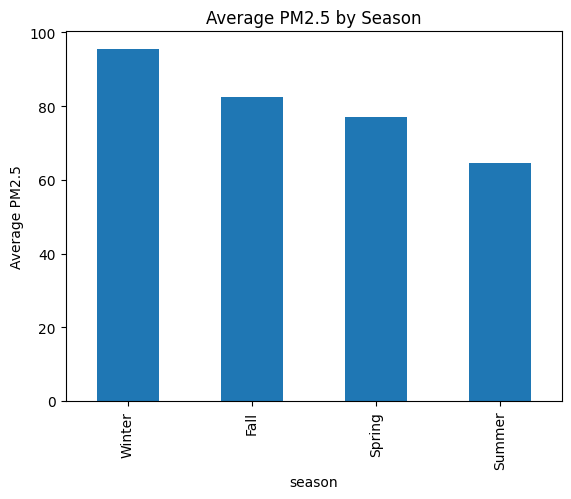

In [76]:
import matplotlib.pyplot as plt

season_pm25 = (
    df.groupby("season")["PM2.5"]
      .mean()
      .sort_values(ascending=False)
)

season_pm25.plot(kind="bar")
plt.title("Average PM2.5 by Season")
plt.ylabel("Average PM2.5")
plt.show()

### 9.3 PM2.5 Distribution by Season

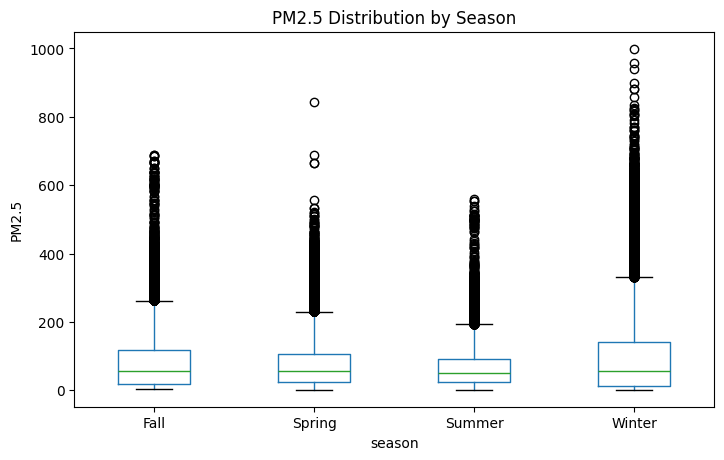

In [79]:
import matplotlib.pyplot as plt

df.boxplot(
    column="PM2.5",
    by="season",
    figsize=(8,5),
    grid=False
)

plt.title("PM2.5 Distribution by Season")
plt.suptitle("")
plt.ylabel("PM2.5")
plt.show()

## 10. Correlation Analysis


### 10.1 Correlation Heatmap

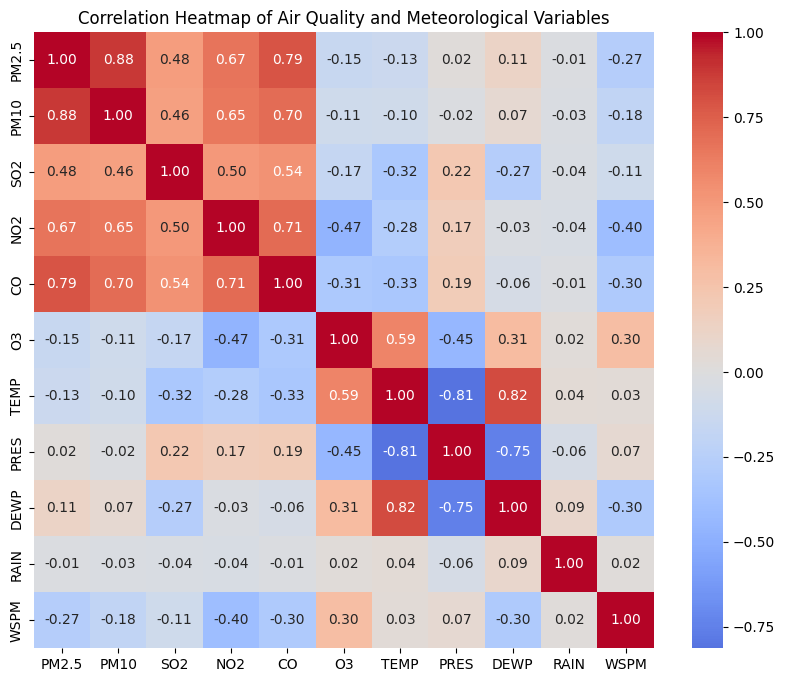

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

pollution_columns = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

corr = df[pollution_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Air Quality and Meteorological Variables")
plt.show()

Major relationships identified:

PM2.5 and PM10: 0.88

PM2.5 and CO: 0.79

PM2.5 and NO2: 0.67

PM2.5 and Wind Speed (WSPM): -0.27

These findings suggest pollutant concentrations are strongly related, while higher wind speeds are associated with lower PM2.5 levels.


### 10.2 PM2.5 and Wind Speed Relationship

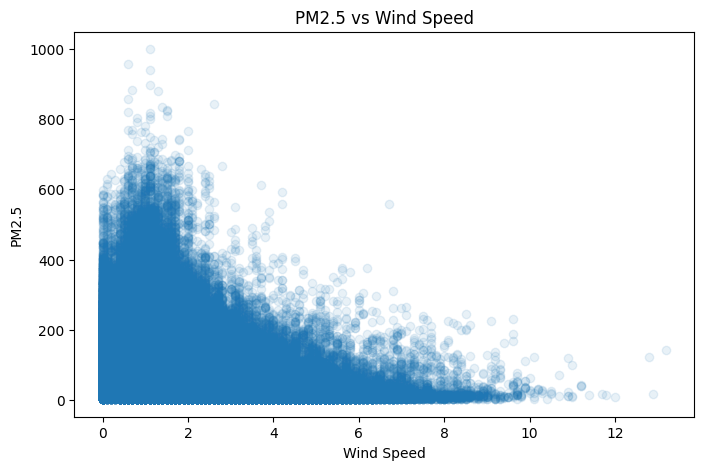

In [86]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["WSPM"],
    df["PM2.5"],
    alpha=0.1
)

plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")
plt.title("PM2.5 vs Wind Speed")

plt.show()

Severe pollution episodes occur primarily during low wind conditions.

High wind speeds appear to reduce the likelihood of extreme PM2.5 events.


## 11. Time-Series Analysis

### 11.1 Monthly PM2.5 Trend by Year

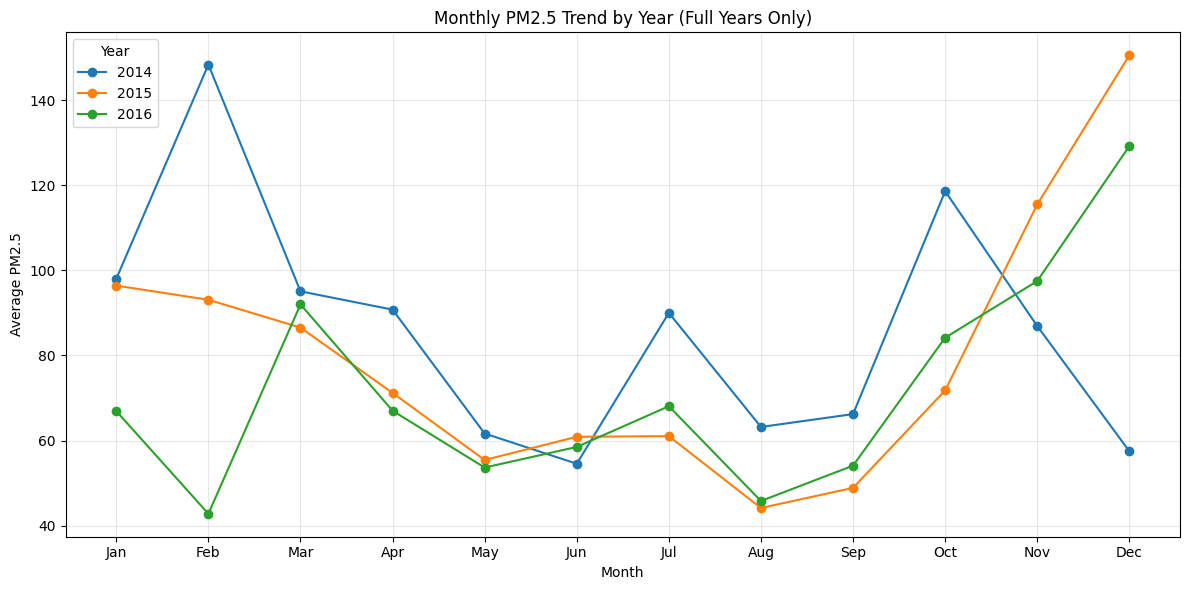

In [91]:
import matplotlib.pyplot as plt

# Use only full years for fair year-over-year comparison
plot_df = df[df["year"].isin([2014, 2015, 2016])]

monthly_yearly = (
    plot_df.groupby(["year", "month"])["PM2.5"]
    .mean()
    .reset_index()
)

months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 6))

for year in sorted(monthly_yearly["year"].unique()):
    temp = monthly_yearly[monthly_yearly["year"] == year]

    plt.plot(
        temp["month"],
        temp["PM2.5"],
        marker="o",
        label=str(year)
    )

plt.xticks(range(1, 13), months)
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Monthly PM2.5 Trend by Year (Full Years Only)")
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Consistent pollution peaks during winter months.

Lower pollution levels during summer months.

Strong recurring seasonal patterns across years.

Seasonal variation appears to have a stronger impact on PM2.5 than year-to-year variation.


## 12. Missing Value Treatment

#### Numerical columns are imputed with median

In [96]:
numeric_cols = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

In [98]:
df_clean = df.copy()

for col in numeric_cols:
    df_clean[col] = (
        df_clean.groupby("station")[col]
        .transform(lambda x: x.fillna(x.median()))
    )

#### Categorical columns are filled with the mode

In [ ]:
# Categorical columns can be filled with the mode

df_clean["wd"] = (
    df_clean.groupby("station")["wd"]
    .transform(
        lambda x: x.fillna(x.mode().iloc[0])
    )
)

Numerical missing values were imputed using station-level medians because pollutant variables are right-skewed and contain extreme values. Missing wind direction values were imputed using the station-level mode.

In [ ]:
# Check for null values after imputation
df_clean.isnull().sum().sort_values(ascending=False)

No          0
year        0
datetime    0
station     0
WSPM        0
wd          0
RAIN        0
DEWP        0
PRES        0
TEMP        0
O3          0
CO          0
NO2         0
SO2         0
PM10        0
PM2.5       0
hour        0
day         0
month       0
season      0
dtype: int64

In [ ]:
#copy the cleaned dataframe to a new CSV file for further analysis and modeling

df_clean.to_csv(
    "../datasets/processed/beijing_air_quality_clean.csv",
    index=False
)

In [102]:
df_clean.sample(5)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,season
240150,29767,2016,7,23,6,155.0,155.0,2.0,57.0,1100.0,2.0,25.8,995.9,24.9,0.0,NW,0.0,Wanliu,2016-07-23 06:00:00,Summer
266135,20688,2015,7,10,23,84.0,104.0,14.0,39.0,800.0,93.0,27.3,1004.9,19.1,0.0,ESE,2.0,Dongsi,2015-07-10 23:00:00,Summer
7866,7867,2014,1,22,18,166.0,184.0,84.0,162.0,3300.0,12.0,0.8,1013.5,-13.7,0.0,SSE,0.0,Gucheng,2014-01-22 18:00:00,Winter
146165,5910,2013,11,2,5,203.0,207.0,13.0,77.0,2300.0,41.0,3.9,1017.0,3.8,0.0,SE,0.5,Guanyuan,2013-11-02 05:00:00,Fall
325355,9780,2014,4,12,11,127.0,151.0,33.0,106.0,1600.0,31.0,19.3,1010.9,0.8,0.0,S,1.9,Aotizhongxin,2014-04-12 11:00:00,Spring


## 13. Statistical Tests

### 1) Do PM2.5 concentrations differ significantly across seasons?

#### One Way ANOVA

In [105]:
from scipy.stats import f_oneway

winter = df_clean[df_clean["season"]=="Winter"]["PM2.5"]
spring = df_clean[df_clean["season"]=="Spring"]["PM2.5"]
summer = df_clean[df_clean["season"]=="Summer"]["PM2.5"]
fall   = df_clean[df_clean["season"]=="Fall"]["PM2.5"]

f_stat, p_value = f_oneway(
    winter,
    spring,
    summer,
    fall
)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.2f}")

F-statistic: 2617.12
P-value: 0.00


Exploratory analysis indicated that average PM2.5 concentrations varied across seasons, with winter exhibiting the highest pollution levels and summer exhibiting the lowest. To determine whether these observed differences were statistically significant, a one-way ANOVA test was conducted. The results showed a statistically significant difference in PM2.5 concentrations across seasons (F = 2617.12, p < 0.001). Therefore, we reject the null hypothesis and conclude that season has a significant effect on PM2.5 levels.

### 2) Is wind speed associated with PM2.5?

#### Pearson Correlation Significance Test

In [107]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df_clean["PM2.5"],
    df_clean["WSPM"]
)

print(corr.round(2))
print(p_value.round(2))

-0.27
0.0


A Pearson correlation analysis was conducted to examine the relationship between wind speed (WSPM) and PM2.5 concentrations. Results showed a statistically significant negative correlation (r = -0.27, p < 0.001), indicating that higher wind speeds are generally associated with lower PM2.5 concentrations. This finding supports the hypothesis that stronger winds help disperse airborne pollutants and reduce particulate matter concentrations.